# EDA – Producción de Pozos de Gas y Petróleo (2026)

**Objetivo:** Realizar un Análisis Exploratorio de Datos (EDA) completo sobre el dataset de producción de pozos de gas y petróleo de Argentina (2026).  
**Dataset:** `produccin-de-pozos-de-gas-y-petrleo-2026.csv`  
**Dimensiones:** 252.475 registros × 38 columnas

---
### Índice
1. Carga y exploración inicial  
2. Tipos de variables  
3. Estadística descriptiva  
4. Análisis de valores nulos  
5. Análisis de variables categóricas  
6. Análisis de variables numéricas  
7. Relaciones entre variables  
8. Visualizaciones  
9. Conclusiones  

## 0. Instalación de dependencias (ejecutar solo si es necesario)

In [ ]:
# Descomentar si alguna librería no está instalada
# !pip install pandas numpy matplotlib seaborn scipy

## 1. Carga y exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
# ─── Ajustar la ruta si el CSV está en otra ubicación ───
RUTA_CSV = 'produccin-de-pozos-de-gas-y-petrleo-2026.csv'

df = pd.read_csv(RUTA_CSV)

print(f'📐 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

📐 Dimensiones: 252,475 filas × 38 columnas


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,idareayacimiento,areayacimiento,cuenca,provincia,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YPF,2026,1,114015,66.39,0.54,221.54,0.0,0.0,0.0,...,CFO,CERRO FORTUNOSO,NEUQUINA,Mendoza,CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,NaN,2026-01-31
1,YPF,2026,1,125335,24.93,5.28,364.97,0.0,0.0,0.0,...,BEH,MANANTIALES BEHR,GOLFO SAN JORGE,Chubut,CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,NaN,2026-01-31
2,YPF,2026,1,114028,0.00,0.00,0.00,0.0,0.0,0.0,...,Z057,CAJON DE OLATINO,NEUQUINA,Mendoza,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2026-01-31
3,YPF,2026,1,155557,0.00,0.00,0.00,0.0,0.0,0.0,...,RNQ,RIO NEUQUEN,NEUQUINA,Neuquén,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2026-01-31
4,YPF,2026,1,114033,0.00,0.00,0.00,0.0,0.0,0.0,...,CFO,CERRO FORTUNOSO,NEUQUINA,Mendoza,CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,NaN,2026-01-31


In [3]:
print('📋 Listado de columnas:\n')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')

📋 Listado de columnas:

   1. idempresa
   2. anio
   3. mes
   4. idpozo
   5. prod_pet
   6. prod_gas
   7. prod_agua
   8. iny_agua
   9. iny_gas
  10. iny_co2
  11. iny_otro
  12. tef
  13. vida_util
  14. tipoextraccion
  15. tipoestado
  16. tipopozo
  17. observaciones
  18. fechaingreso
  19. rectificado
  20. habilitado
  21. idusuario
  22. empresa
  23. sigla
  24. formprod
  25. profundidad
  26. formacion
  27. idareapermisoconcesion
  28. areapermisoconcesion
  29. idareayacimiento
  30. areayacimiento
  31. cuenca
  32. provincia
  33. tipo_de_recurso
  34. proyecto
  35. clasificacion
  36. subclasificacion
  37. sub_tipo_recurso
  38. fecha_data


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252475 entries, 0 to 252474
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               252475 non-null  object 
 1   anio                    252475 non-null  int64  
 2   mes                     252475 non-null  int64  
 3   idpozo                  252475 non-null  int64  
 4   prod_pet                252475 non-null  float64
 5   prod_gas                252475 non-null  float64
 6   prod_agua               252475 non-null  float64
 7   iny_agua                252475 non-null  float64
 8   iny_gas                 252475 non-null  float64
 9   iny_co2                 252475 non-null  float64
 10  iny_otro                252475 non-null  float64
 11  tef                     252475 non-null  float64
 12  vida_util               26605 non-null   float64
 13  tipoextraccion          252462 non-null  object 
 14  tipoestado          

## 2. Tipos de variables

In [5]:
# Clasificación manual con base en el dominio del problema
tipos = {
    'Identificadores / Claves': [
        'idempresa', 'idpozo', 'idusuario', 'idareapermisoconcesion', 'idareayacimiento'
    ],
    'Temporales': [
        'anio', 'mes', 'fechaingreso', 'fecha_data'
    ],
    'Numéricas – Producción / Inyección': [
        'prod_pet', 'prod_gas', 'prod_agua',
        'iny_agua', 'iny_gas', 'iny_co2', 'iny_otro'
    ],
    'Numéricas – Operativas': [
        'tef', 'vida_util', 'profundidad'
    ],
    'Categóricas – Tipo de pozo': [
        'tipoextraccion', 'tipoestado', 'tipopozo'
    ],
    'Categóricas – Geográficas': [
        'cuenca', 'provincia', 'areapermisoconcesion', 'areayacimiento'
    ],
    'Categóricas – Recurso': [
        'tipo_de_recurso', 'clasificacion', 'subclasificacion', 'sub_tipo_recurso'
    ],
    'Categóricas – Administrativas': [
        'empresa', 'sigla', 'formprod', 'formacion',
        'proyecto', 'rectificado', 'habilitado'
    ],
    'Sin uso analítico directo': ['observaciones']
}

for grupo, cols in tipos.items():
    print(f'\n🔹 {grupo} ({len(cols)} variables)')
    print('   ', ' | '.join(cols))


🔹 Identificadores / Claves (5 variables)
    idempresa | idpozo | idusuario | idareapermisoconcesion | idareayacimiento

🔹 Temporales (4 variables)
    anio | mes | fechaingreso | fecha_data

🔹 Numéricas – Producción / Inyección (7 variables)
    prod_pet | prod_gas | prod_agua | iny_agua | iny_gas | iny_co2 | iny_otro

🔹 Numéricas – Operativas (3 variables)
    tef | vida_util | profundidad

🔹 Categóricas – Tipo de pozo (3 variables)
    tipoextraccion | tipoestado | tipopozo

🔹 Categóricas – Geográficas (4 variables)
    cuenca | provincia | areapermisoconcesion | areayacimiento

🔹 Categóricas – Recurso (4 variables)
    tipo_de_recurso | clasificacion | subclasificacion | sub_tipo_recurso

🔹 Categóricas – Administrativas (7 variables)
    empresa | sigla | formprod | formacion | proyecto | rectificado | habilitado

🔹 Sin uso analítico directo (1 variables)
    observaciones


In [6]:
# Conteo por tipo de dato Pandas
tipo_conteo = df.dtypes.value_counts().reset_index()
tipo_conteo.columns = ['Tipo de dato', 'Cantidad de columnas']
print(tipo_conteo.to_string(index=False))

Tipo de dato  Cantidad de columnas
      object                    24
     float64                    10
       int64                     4


## 3. Estadística descriptiva

In [7]:
vars_numericas = ['prod_pet', 'prod_gas', 'prod_agua',
                  'iny_agua', 'iny_gas', 'iny_co2', 'iny_otro',
                  'tef', 'vida_util', 'profundidad']

desc = df[vars_numericas].describe().T
desc['cv (%)'] = (desc['std'] / desc['mean'].replace(0, np.nan) * 100).round(1)
desc['skewness'] = df[vars_numericas].skew().round(3)
desc['kurtosis'] = df[vars_numericas].kurtosis().round(3)

pd.set_option('display.float_format', '{:,.2f}'.format)
desc

,count,mean,std,min,25%,50%,75%,max,cv (%),skewness,kurtosis
prod_pet,"252,475.00",50.03,343.96,-0.00,0.00,0.00,3.61,"14,578.72",687.50,15.97,339.23
prod_gas,"252,475.00",49.22,813.55,0.00,0.00,0.00,0.00,"104,141.90","1,652.90",75.55,"7,690.89"
prod_agua,"252,475.00",316.69,"1,104.69",0.00,0.00,0.00,5.65,"28,671.30",348.80,5.93,50.06
iny_agua,"252,475.00",317.00,"1,922.33",0.00,0.00,0.00,0.00,"178,089.89",606.40,21.22,"1,070.21"
iny_gas,"252,475.00",23.89,"7,609.48",0.00,0.00,0.00,0.00,"2,791,887.52","31,855.80",350.15,"123,986.71"
iny_co2,"252,475.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00
iny_otro,"252,475.00",1.43,211.72,0.00,0.00,0.00,0.00,"40,630.03","14,769.00",160.51,"26,841.25"
tef,"252,475.00",9.07,13.47,0.00,0.00,0.00,27.88,92.83,148.60,0.85,-1.22
vida_util,"26,605.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00
profundidad,"252,475.00","1,716.17","1,752.04",0.00,"1,045.00","1,600.00","2,360.00","378,939.00",102.10,119.02,"25,534.36"


> **Observaciones:**  
> - `prod_pet`, `prod_gas` y `prod_agua` presentan asimetría positiva alta → distribuciones muy sesgadas a la derecha (pocos pozos producen muchísimo).  
> - `profundidad` tiene un máximo de 378.939 m, probablemente un dato atípico que requiere revisión.  
> - `vida_util` tiene un 89% de valores nulos, lo que limita su uso analítico.

## 4. Análisis de valores nulos

In [8]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
}).sort_values('% Nulos', ascending=False)

nulos_con_datos = nulos[nulos['Nulos'] > 0]
print(f'Columnas con valores nulos: {len(nulos_con_datos)} de {df.shape[1]}\n')
print(nulos_con_datos.to_string())

Columnas con valores nulos: 11 de 38

                   Nulos  % Nulos
sub_tipo_recurso  237918    94.23
vida_util         225870    89.46
observaciones     209043    82.80
subclasificacion   50031    19.82
clasificacion      50031    19.82
formacion           8357     3.31
formprod            8037     3.18
tipopozo              13     0.01
tipoestado            13     0.01
tipoextraccion        13     0.01
cuenca                 9     0.00


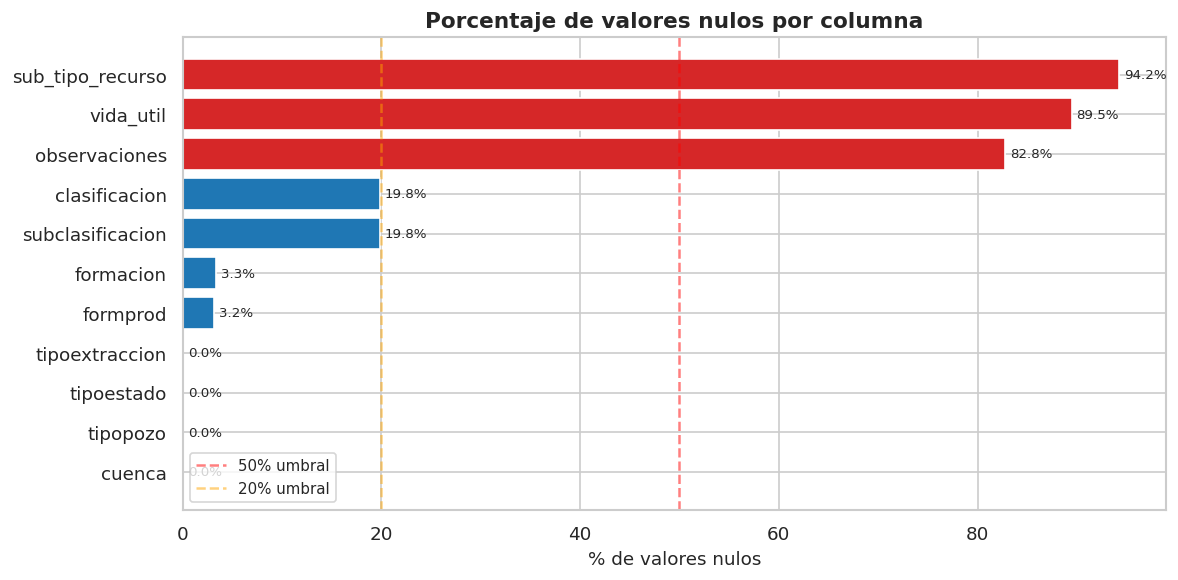

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

nulos_plot = nulos_con_datos.sort_values('% Nulos')
colores = ['#d62728' if p > 50 else '#ff7f0e' if p > 20 else '#1f77b4'
           for p in nulos_plot['% Nulos']]

bars = ax.barh(nulos_plot.index, nulos_plot['% Nulos'], color=colores)
ax.set_xlabel('% de valores nulos', fontsize=11)
ax.set_title('Porcentaje de valores nulos por columna', fontsize=13, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% umbral')
ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='20% umbral')
ax.legend(fontsize=9)

for bar, val in zip(bars, nulos_plot['% Nulos']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('grafico_01_valores_nulos.png', bbox_inches='tight')
plt.show()

## 5. Análisis de variables categóricas

In [10]:
vars_cat = ['tipoextraccion', 'tipoestado', 'tipopozo',
            'cuenca', 'provincia', 'tipo_de_recurso',
            'clasificacion', 'subclasificacion']

for col in vars_cat:
    vc = df[col].value_counts(dropna=False)
    print(f'\n📊 {col} ({df[col].nunique(dropna=True)} categorías únicas)')
    print(vc.to_string())


📊 tipoextraccion (11 categorías únicas)
tipoextraccion
Sin Sistema de Extracción    125910
Bombeo Mecánico               65078
Surgencia Natural             19351
Electrosumergible             17299
Cavidad Progresiva            15313
Pistoneo (Swabbing)            3998
Plunger Lift                   2906
Gas Lift                       2204
Otros Tipos de Extracción       347
Bombeo Hidráulico                35
Jet Pump                         21
NaN                              13

📊 tipoestado (16 categorías únicas)
tipoestado
Extracción Efectiva                   76599
Abandonado                            58962
En Reserva para Recup. Sec./Asist.    27054
En Estudio                            25992
Parado Transitoriamente               17899
En Inyección Efectiva                 17756
A Abandonar                            8023
En Espera de Reparación                6065
Abandono Temporario                    4117
Otras Situación Inactivo               3884
Parado Alta Relación Agu

In [11]:
# Top 10 empresas por número de registros
top_empresas = df['empresa'].value_counts().head(10)
print('Top 10 empresas por registros:')
print(top_empresas.to_string())

Top 10 empresas por registros:
empresa
YPF S.A.                                 46876
PAN AMERICAN ENERGY SL                   23236
PECOM SERVICIOS ENERGIA SAU              19825
PETROLEOS SUDAMERICANOS S.A.             14391
CGC ENERGIA SAU                          12964
COMPAÑÍAS ASOCIADAS PETROLERAS S.A.      11724
QUINTANA E&P ARGENTINA S.R.L.            11595
PATAGONIA RESOURCES S.A.                  9357
Clear Petroleum S.A.                      8763
COMPAÑÍA GENERAL DE COMBUSTIBLES S.A.     8663


## 6. Distribución de variables numéricas

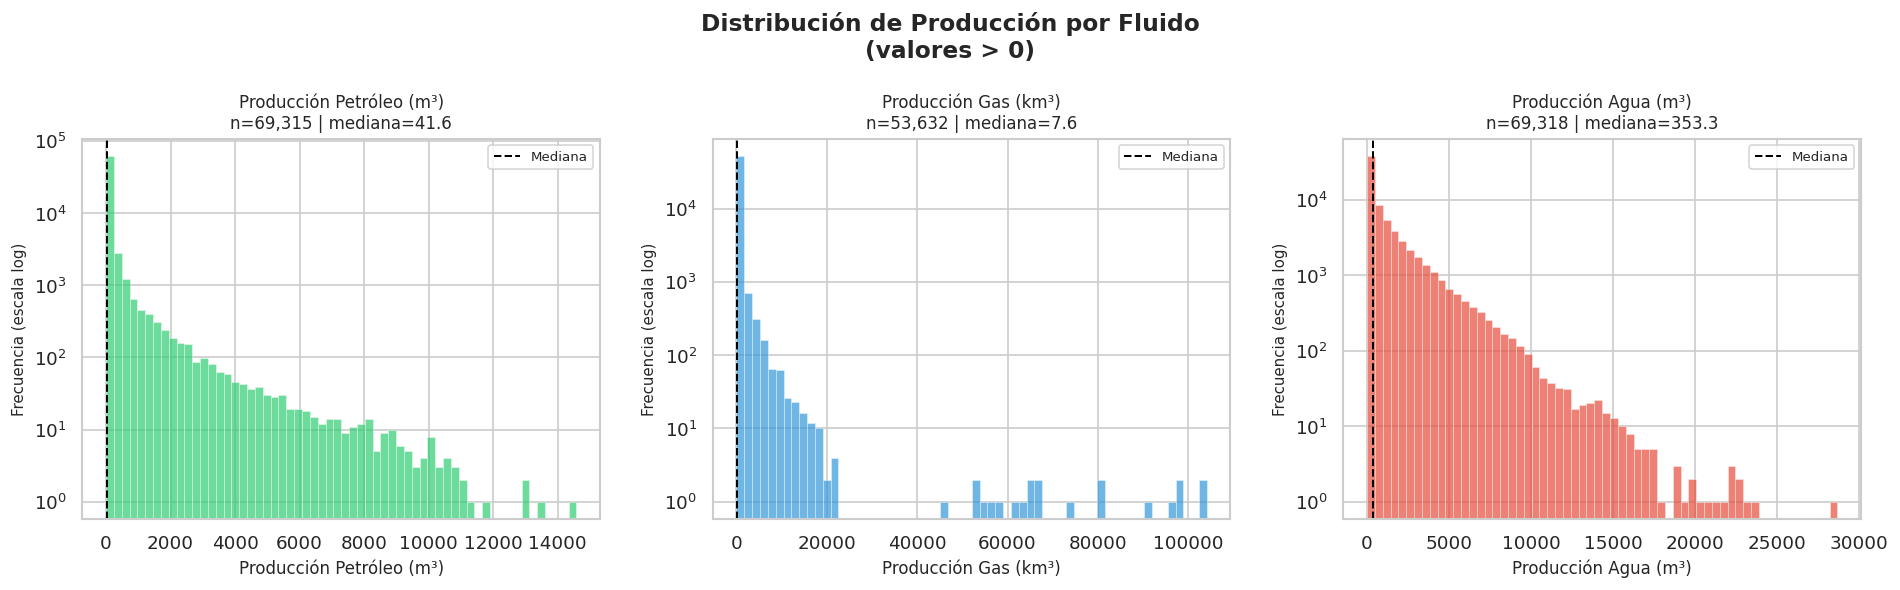

In [12]:
# ── GRÁFICO 2: Distribuciones de producción (histogramas + KDE) ──
vars_prod = ['prod_pet', 'prod_gas', 'prod_agua']
labels    = ['Producción Petróleo (m³)', 'Producción Gas (km³)', 'Producción Agua (m³)']
colores   = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Producción por Fluido\n(valores > 0)', fontsize=14, fontweight='bold')

for ax, col, label, color in zip(axes, vars_prod, labels, colores):
    data = df[df[col] > 0][col]
    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Frecuencia (escala log)', fontsize=9)
    ax.set_title(f'{label}\nn={len(data):,} | mediana={data.median():,.1f}', fontsize=10)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label='Mediana')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('grafico_02_distribuciones_produccion.png', bbox_inches='tight')
plt.show()

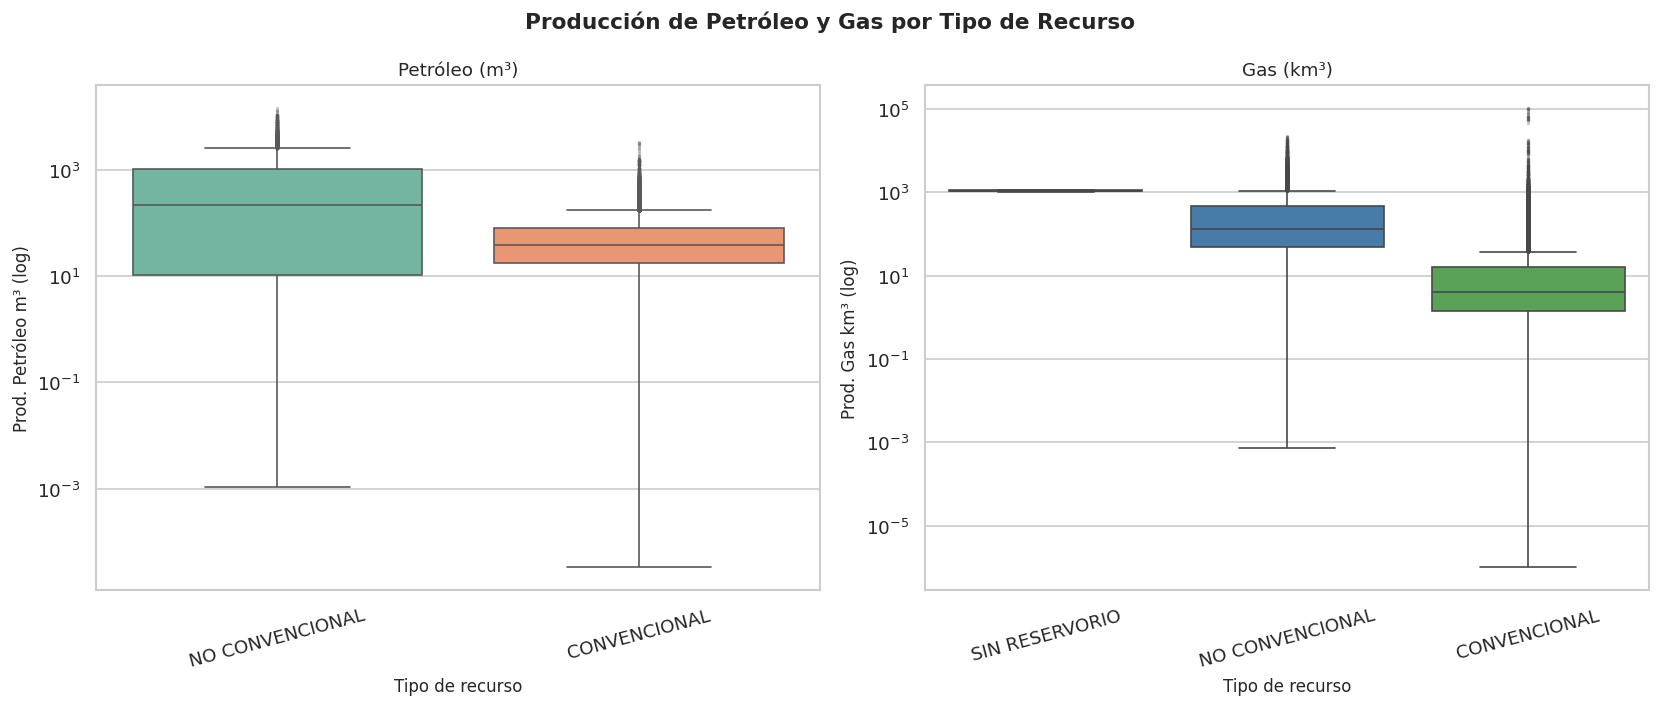

In [13]:
# ── GRÁFICO 3: Boxplots de producción por tipo de recurso ──
df_box = df[(df['prod_pet'] > 0) | (df['prod_gas'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Producción de Petróleo y Gas por Tipo de Recurso', fontsize=13, fontweight='bold')

# Petróleo
df_pet = df_box[df_box['prod_pet'] > 0]
orden_pet = df_pet.groupby('tipo_de_recurso')['prod_pet'].median().sort_values(ascending=False).index
sns.boxplot(data=df_pet, x='tipo_de_recurso', y='prod_pet', order=orden_pet,
            palette='Set2', ax=axes[0], flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_yscale('log')
axes[0].set_xlabel('Tipo de recurso', fontsize=10)
axes[0].set_ylabel('Prod. Petróleo m³ (log)', fontsize=10)
axes[0].set_title('Petróleo (m³)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Gas
df_gas = df_box[df_box['prod_gas'] > 0]
orden_gas = df_gas.groupby('tipo_de_recurso')['prod_gas'].median().sort_values(ascending=False).index
sns.boxplot(data=df_gas, x='tipo_de_recurso', y='prod_gas', order=orden_gas,
            palette='Set1', ax=axes[1], flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_yscale('log')
axes[1].set_xlabel('Tipo de recurso', fontsize=10)
axes[1].set_ylabel('Prod. Gas km³ (log)', fontsize=10)
axes[1].set_title('Gas (km³)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('grafico_03_boxplot_tipo_recurso.png', bbox_inches='tight')
plt.show()

## 7. Relaciones entre variables

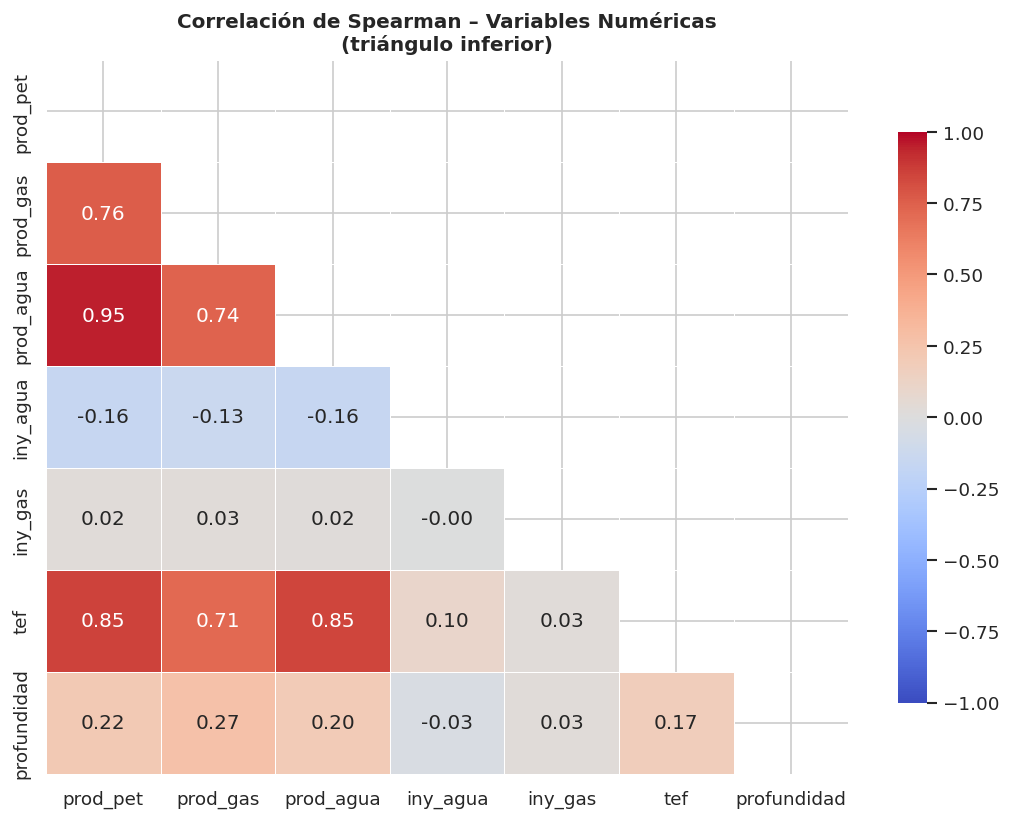

In [14]:
# Correlación entre variables numéricas
vars_corr = ['prod_pet', 'prod_gas', 'prod_agua',
             'iny_agua', 'iny_gas', 'tef', 'profundidad']

corr_matrix = df[vars_corr].corr(method='spearman')   # Spearman por distribuciones sesgadas

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación de Spearman – Variables Numéricas\n(triángulo inferior)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_04_correlacion_spearman.png', bbox_inches='tight')
plt.show()

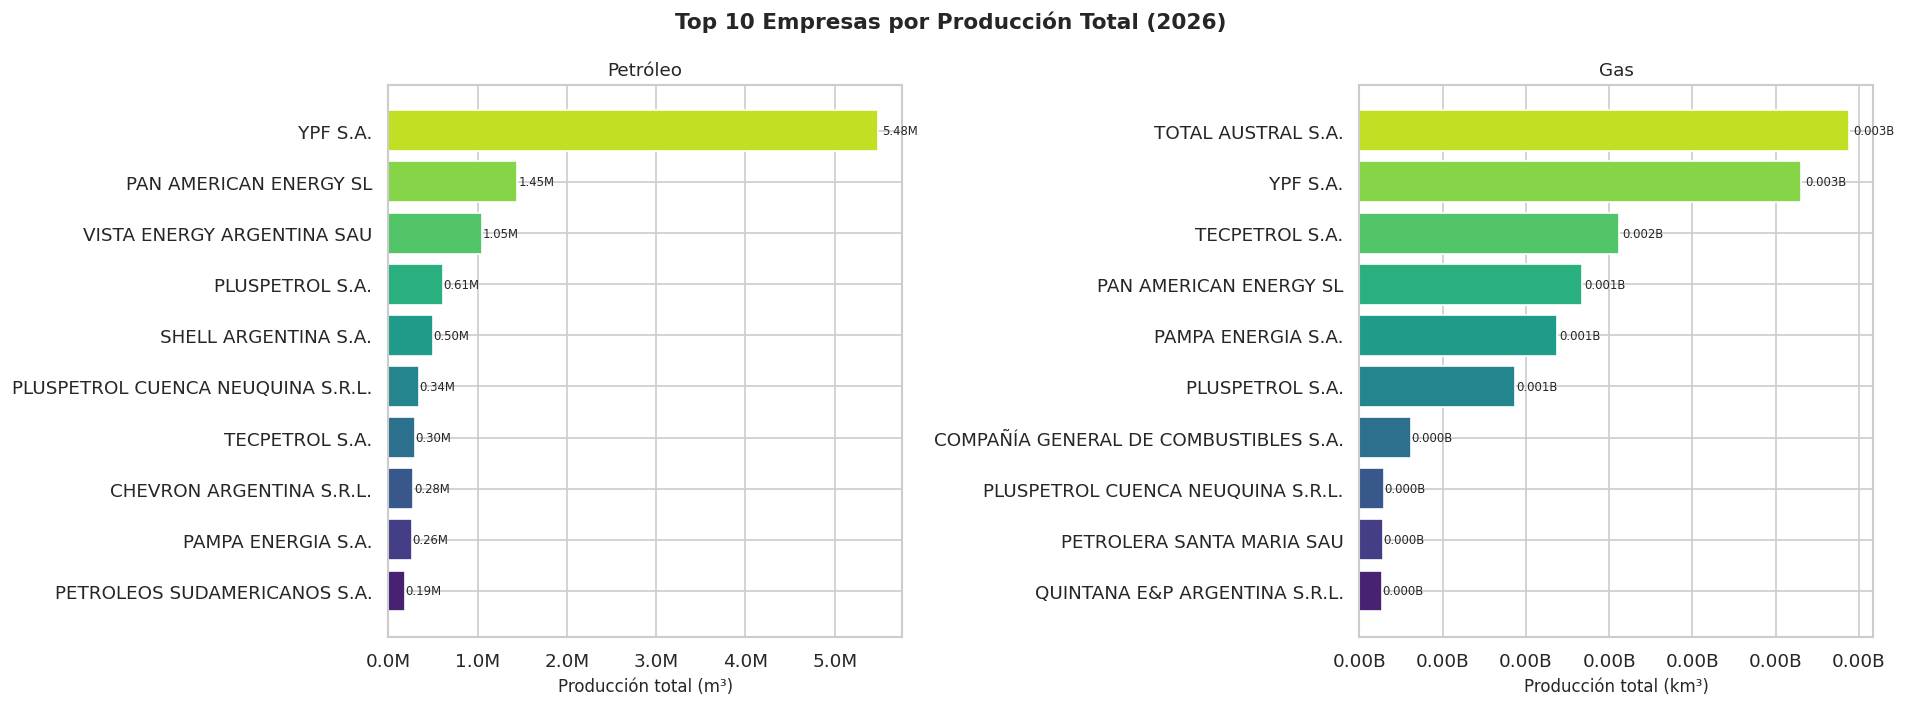

In [ ]:
# ── GRÁFICO 5: Top empresas por producción ──
top_n = 10
top_emp_pet = df.groupby('empresa')['prod_pet'].sum().sort_values(ascending=False).head(top_n)
top_emp_gas = df.groupby('empresa')['prod_gas'].sum().sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Top {top_n} Empresas por Producción Total (2026)', fontsize=13, fontweight='bold')

palette = sns.color_palette('viridis', top_n)

bars1 = axes[0].barh(top_emp_pet.index[::-1], top_emp_pet.values[::-1], color=palette)
axes[0].set_xlabel('Producción total (m³)', fontsize=10)
axes[0].set_title('Petróleo', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar in bars1:
    w = bar.get_width()
    axes[0].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{w/1e6:.2f}M', va='center', fontsize=7)

bars2 = axes[1].barh(top_emp_gas.index[::-1], top_emp_gas.values[::-1], color=palette)
axes[1].set_xlabel('Producción total (km³)', fontsize=10)
axes[1].set_title('Gas', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.2f}B'))
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                 f'{w/1e9:.3f}B', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('grafico_06_top_empresas_produccion.png', bbox_inches='tight')
plt.show()

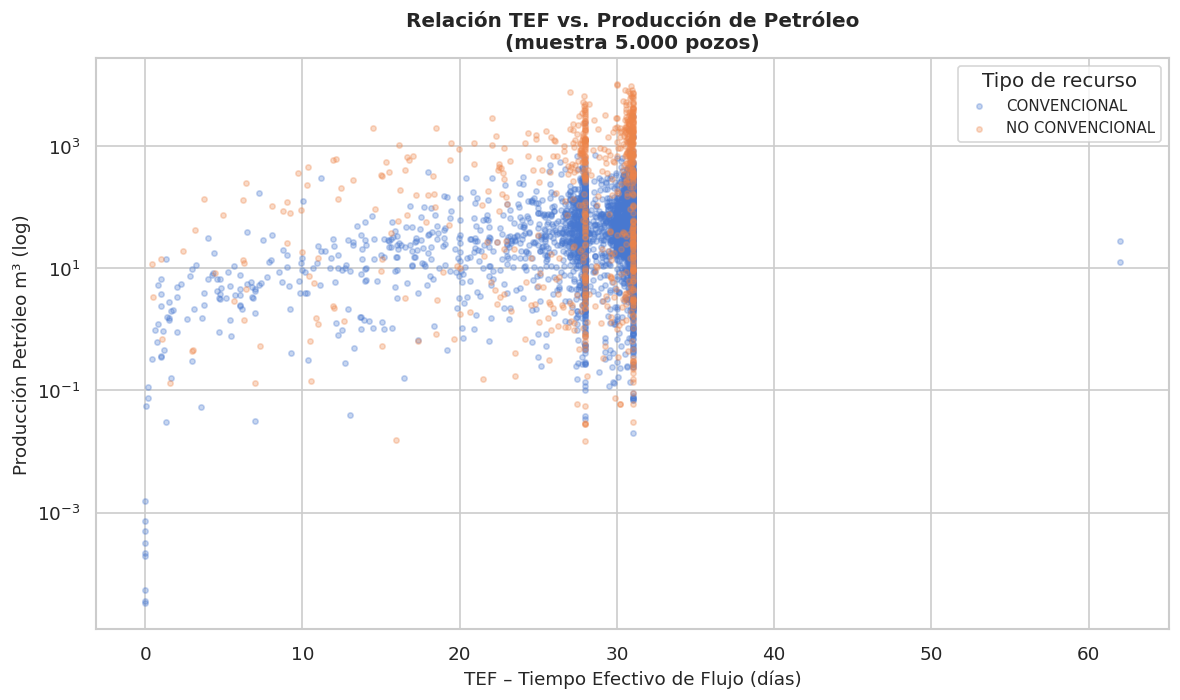

Correlación Spearman TEF–Prod.Petróleo: r=0.130, p-value=2.98e-20


In [ ]:
# ── GRÁFICO 6: Scatter – Petróleo vs. TEF coloreado por tipo de recurso ──
df_scatter = df[(df['prod_pet'] > 0) & (df['tef'] > 0)].sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

for recurso, grp in df_scatter.groupby('tipo_de_recurso'):
    ax.scatter(grp['tef'], grp['prod_pet'], alpha=0.3, s=10, label=recurso)

ax.set_yscale('log')
ax.set_xlabel('TEF – Tiempo Efectivo de Flujo (días)', fontsize=11)
ax.set_ylabel('Producción Petróleo m³ (log)', fontsize=11)
ax.set_title('Relación TEF vs. Producción de Petróleo\n(muestra 5.000 pozos)', fontsize=12, fontweight='bold')
ax.legend(title='Tipo de recurso', fontsize=9)

plt.tight_layout()
plt.savefig('grafico_07_scatter_tef_produccion.png', bbox_inches='tight')
plt.show()

# Correlación TEF – prod_pet
r, p = stats.spearmanr(df_scatter['tef'], df_scatter['prod_pet'])
print(f'Correlación Spearman TEF–Prod.Petróleo: r={r:.3f}, p-value={p:.2e}')

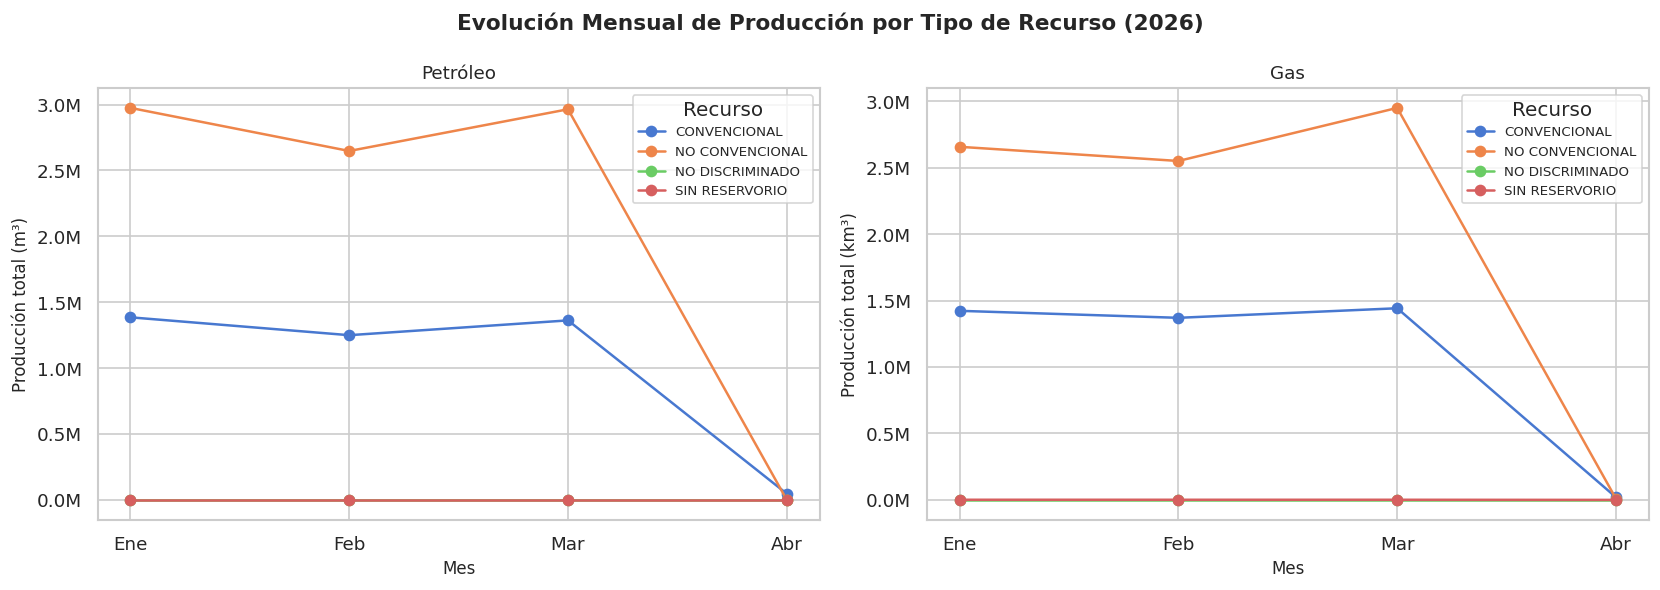

In [ ]:
# ── GRÁFICO 7: Evolución mensual de producción por tipo de recurso ──
evol = (
    df.groupby(['mes', 'tipo_de_recurso'])[['prod_pet', 'prod_gas']]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución Mensual de Producción por Tipo de Recurso (2026)', fontsize=13, fontweight='bold')

meses_labels = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr'}

for recurso in evol['tipo_de_recurso'].unique():
    sub = evol[evol['tipo_de_recurso'] == recurso]
    axes[0].plot(sub['mes'], sub['prod_pet'], marker='o', label=recurso)
    axes[1].plot(sub['mes'], sub['prod_gas'], marker='o', label=recurso)

for ax, titulo, unidad in zip(axes, ['Petróleo', 'Gas'], ['m³', 'km³']):
    ax.set_xlabel('Mes', fontsize=10)
    ax.set_ylabel(f'Producción total ({unidad})', fontsize=10)
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(meses_labels.keys()))
    ax.set_xticklabels(list(meses_labels.values()))
    ax.legend(title='Recurso', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('grafico_08_evolucion_mensual.png', bbox_inches='tight')
plt.show()

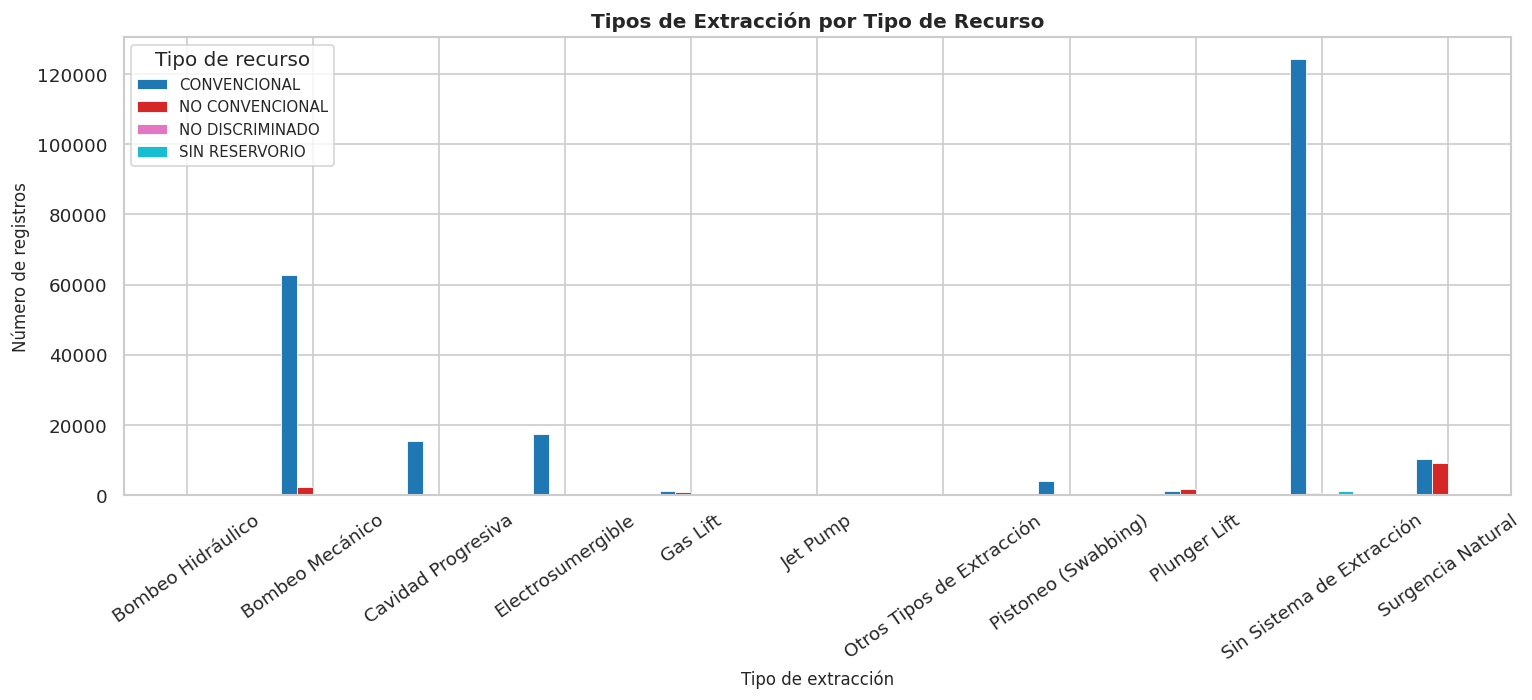

In [ ]:
# ── GRÁFICO 8: Distribución de tipos de extracción por tipo de recurso ──
tabla = (
    df.groupby(['tipo_de_recurso', 'tipoextraccion'])
    .size()
    .reset_index(name='count')
    .dropna()
)

fig, ax = plt.subplots(figsize=(13, 6))

pivot_ext = tabla.pivot(index='tipoextraccion', columns='tipo_de_recurso', values='count').fillna(0)
pivot_ext.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Tipo de extracción', fontsize=10)
ax.set_ylabel('Número de registros', fontsize=10)
ax.set_title('Tipos de Extracción por Tipo de Recurso', fontsize=12, fontweight='bold')
ax.legend(title='Tipo de recurso', fontsize=9)
ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('grafico_09_extraccion_x_recurso.png', bbox_inches='tight')
plt.show()

## 8. Estadísticas por grupos clave

In [20]:
# Producción media por cuenca
cuenca_stats = (
    df.groupby('cuenca')[['prod_pet', 'prod_gas', 'prod_agua']]
    .agg(['mean', 'median', 'sum'])
    .round(2)
)
cuenca_stats.columns = ['_'.join(c) for c in cuenca_stats.columns]
print('=== Estadísticas por cuenca ===')
cuenca_stats.sort_values('prod_pet_sum', ascending=False)

=== Estadísticas por cuenca ===


,prod_pet_mean,prod_pet_median,prod_pet_sum,prod_gas_mean,prod_gas_median,prod_gas_sum,prod_agua_mean,prod_agua_median,prod_agua_sum
cuenca,,,,,,,,,
NEUQUINA,99.28,0.00,"9,718,067.80",92.75,0.00,"9,079,259.17",211.04,0.00,"20,657,176.43"
GOLFO SAN JORGE,19.32,0.00,"2,538,787.33",5.89,0.00,"773,886.31",390.94,0.00,"51,367,476.74"
CUYANA,17.40,0.00,"192,461.39",0.73,0.00,"8,100.76",596.48,0.00,"6,595,827.52"
AUSTRAL,15.32,0.00,"144,116.50",246.78,0.00,"2,320,926.08",109.08,0.00,"1,025,925.27"
NOROESTE,14.51,0.00,"38,878.36",91.33,0.00,"244,769.00",115.83,0.00,"310,429.69"
CAÑADON ASFALTO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
NORESTE,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ÑIRIHUAU,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# Estado de los pozos
estado_pct = df['tipoestado'].value_counts(normalize=True).mul(100).round(2)
print('Distribución de estados de pozos (%):')
print(estado_pct.to_string())

## 9. Conclusiones del EDA

| Dimensión | Hallazgo |
|-----------|----------|
| **Dataset** | 252.475 registros, 38 variables, período enero–abril 2026 |
| **Calidad** | `vida_util` (89% nulos) y `sub_tipo_recurso` (94% nulos) son prácticamente inutilizables. `clasificacion`/`subclasificacion` tienen ~20% nulos |
| **Producción** | Distribuciones muy asimétricas (sesgo positivo): la mayoría de pozos produce poco; unos pocos producen volúmenes enormes |
| **Cuencas** | NEUQUINA y GOLFO SAN JORGE concentran la mayor producción de petróleo; NEUQUINA lidera en gas |
| **Recursos** | Los recursos NO CONVENCIONALES (shale/tight) muestran producciones de gas significativamente más altas que los convencionales |
| **Empresas** | YPF domina ampliamente tanto en petróleo como en gas |
| **TEF** | Correlación positiva moderada con producción de petróleo (r ≈ 0.4–0.5 Spearman) |
| **Tipos de extracción** | Bombeo mecánico y surgencia natural son los más frecuentes en convencionales; en no convencionales predomina surgencia natural |
| **Tendencia** | La producción se mantiene relativamente estable entre enero y abril, con ligeras variaciones por cuenca |